# Лабораторная работа: ансамблевая классификация


## 1. Формулировка задания

1. Разработать программу, выполняющую классификацию набора данных с помощью **ансамблевой
   техники**. Параметры программы: набор данных, ансамблевая техника (бэггинг, случайный лес
   или бустинг), количество участников ансамбля и параметры выбранной техники.
2. Провести эксперименты на наборе данных из задания «Классификация с помощью дерева
   решений», варьируя **количество участников ансамбля от 50 до 100 с шагом 10**.
3. Визуализировать показатели качества классификации в зависимости от количества участников
   ансамбля, нанеся на диаграмму значения, полученные в предыдущем задании.
4. Подготовить отчёт в формате PDF.

## 2. Идея ансамблевой классификации

Одно дерево решений — неустойчивый классификатор: небольшое изменение обучающей выборки
меняет выбор атрибута в корне и перестраивает всё дерево. Ансамбль обучает **много** таких
классификаторов на слегка различающихся данных и объединяет их ответы голосованием.
Случайные ошибки отдельных участников при этом взаимно гасятся.

Реализованы три техники:

| Техника | Как получают разнообразие участников | Как объединяют ответы |
|---|---|---|
| **Бэггинг** | каждое дерево учится на своей бутстрэп-выборке (выбор $n$ записей с возвратом) | простое большинство голосов |
| **Случайный лес** | бутстрэп **плюс** в каждом узле рассматривается случайное подмножество атрибутов | простое большинство голосов |
| **Бустинг** (AdaBoost) | участники обучаются последовательно, каждый следующий — на записях, где ошибся предыдущий | взвешенное голосование, вес участника тем больше, чем он точнее |

Бэггинг и случайный лес обучают участников **независимо** и борются с разбросом (variance):
каждое дерево переобучено по-своему, усреднение это сглаживает. Бустинг обучает участников
**последовательно** и борется со смещением (bias): каждое дерево исправляет ошибки
предыдущих, поэтому участниками служат заведомо слабые неглубокие деревья.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["font.size"] = 11

RANDOM_SEED = 42

COLUMNS = ["age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
           "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
           "hours-per-week", "native-country", "income"]
CONTINUOUS = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
FEATURES = [c for c in COLUMNS if c not in ("income", "fnlwgt")]
TARGET = "income"
POSITIVE = ">50K"
NEGATIVE = "<=50K"
N_THRESHOLDS = 16


def load_dataset(path, skiprows=0):
    df = pd.read_csv(path, header=None, names=COLUMNS, skiprows=skiprows,
                     skipinitialspace=True, na_values=["?"])
    df[TARGET] = df[TARGET].astype(str).str.rstrip(".")
    return df.fillna("Unknown")


df_train = load_dataset("adult.data")
df_test = load_dataset("adult.test", skiprows=1)
print(f"Обучающая выборка: {len(df_train)} записей")
print(f"Тестовая выборка:  {len(df_test)} записей")

Обучающая выборка: 32561 записей
Тестовая выборка:  16281 записей


## 3. Базовый классификатор

Участник ансамбля — дерево решений из предыдущей работы. По сравнению с ней в класс внесены
два изменения:

* дерево запоминает свой список атрибутов (`self.features = list(X.columns)`), а не берёт
  глобальный, — чтобы можно было обучать его на подмножестве признаков;
* добавлен параметр `max_features`: если он задан, **в каждом узле** рассматривается
  случайное подмножество атрибутов такого размера. Это и есть механизм случайного леса.

Остальной код — разбиение по критерию, обработка числовых и категориальных атрибутов,
условия остановки — без изменений.

In [2]:
def entropy(counts):
    p = counts[counts > 0] / counts.sum()
    return -(p * np.log2(p)).sum()


def gini(counts):
    p = counts / counts.sum()
    return 1 - (p * p).sum()


def classification_metrics(y_true, y_pred, positive=POSITIVE):
    """Accuracy, precision, recall и F-мера относительно положительного класса."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    tp = ((y_pred == positive) & (y_true == positive)).sum()
    fp = ((y_pred == positive) & (y_true != positive)).sum()
    fn = ((y_pred != positive) & (y_true == positive)).sum()

    accuracy = (y_pred == y_true).mean()
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}

In [3]:
class DecisionTree:
    """
    Дерево решений (из предыдущей работы).
      criterion    — information_gain | gain_ratio | gini
      max_depth    — предельная глубина
      min_samples  — минимальный размер узла, который ещё разбивается
      max_features — сколько случайных атрибутов рассматривать в узле (для случайного леса)
    """

    def __init__(self, criterion="gini", max_depth=8, min_samples=100,
                 max_features=None, seed=0):
        self.criterion = criterion
        self.max_depth = max_depth
        self.min_samples = min_samples
        self.max_features = max_features
        self.rng = np.random.default_rng(seed)
        self.impurity = gini if criterion == "gini" else entropy

    def fit(self, X, y):
        self.features = list(X.columns)      # дерево может обучаться на подмножестве атрибутов
        self.classes_ = np.array(sorted(pd.unique(y)))
        self.n_leaves = 0
        self.root = self._build(X.reset_index(drop=True), np.asarray(y), depth=0, used=set())
        return self

    def _counts(self, y):
        return np.array([(y == c).sum() for c in self.classes_], dtype=float)

    def _build(self, X, y, depth, used):
        counts = self._counts(y)
        node = {"n": len(y), "counts": counts, "leaf": True,
                "class": self.classes_[counts.argmax()]}
        if depth >= self.max_depth or len(y) < self.min_samples or (counts > 0).sum() <= 1:
            self.n_leaves += 1
            return node

        split = self._best_split(X, y, used)
        if split is None:
            self.n_leaves += 1
            return node

        attr, labels, masks, threshold = split
        node.update({"leaf": False, "attr": attr, "labels": labels, "threshold": threshold})
        next_used = used if attr in CONTINUOUS else used | {attr}
        node["children"] = [self._build(X[m], y[m], depth + 1, next_used) for m in masks]
        return node

    def _score(self, y, masks, parent_impurity):
        n = len(y)
        children = sum((m.sum() / n) * self.impurity(self._counts(y[m])) for m in masks)
        gain = parent_impurity - children
        if self.criterion != "gain_ratio":
            return gain, gain
        p = np.array([m.sum() / n for m in masks])
        p = p[p > 0]
        split_info = -(p * np.log2(p)).sum()
        return gain, (gain / split_info if split_info > 1e-12 else 0.0)

    def _best_split(self, X, y, used):
        parent_impurity = self.impurity(self._counts(y))
        best_per_attr = []

        attrs = self.features
        if self.max_features and self.max_features < len(attrs):
            # случайный лес: в каждом узле рассматривается случайное подмножество атрибутов
            attrs = self.rng.choice(attrs, self.max_features, replace=False)

        for attr in attrs:
            col = X[attr].to_numpy()
            options = []
            if attr in CONTINUOUS:
                for t in np.unique(np.quantile(col, np.linspace(0, 1, N_THRESHOLDS + 2)[1:-1])):
                    masks = [col <= t, col > t]
                    if min(m.sum() for m in masks) >= 10:
                        gain, score = self._score(y, masks, parent_impurity)
                        options.append((gain, score, [f"<= {t:g}", f"> {t:g}"], masks, t))
            elif attr not in used:
                values = sorted(pd.unique(col))
                if len(values) >= 2:
                    masks = [col == v for v in values]
                    gain, score = self._score(y, masks, parent_impurity)
                    options.append((gain, score, [str(v) for v in values], masks, None))
            if options:
                key = 0 if self.criterion == "gain_ratio" else 1
                best_per_attr.append((attr, max(options, key=lambda o: o[key])))

        if not best_per_attr:
            return None

        if self.criterion == "gain_ratio":
            mean_gain = np.mean([opt[0] for _, opt in best_per_attr])
            best_per_attr = [c for c in best_per_attr if c[1][0] >= mean_gain] or best_per_attr

        attr, (gain, score, labels, masks, threshold) = max(best_per_attr, key=lambda c: c[1][1])
        return (attr, labels, masks, threshold) if score > 1e-7 else None

    def predict(self, X):
        return np.array([self._classify(row) for row in X[self.features].to_dict("records")])

    def _classify(self, row):
        node = self.root
        while not node["leaf"]:
            value = row[node["attr"]]
            if node["attr"] in CONTINUOUS:
                node = node["children"][0 if value <= node["threshold"] else 1]
            elif str(value) in node["labels"]:
                node = node["children"][node["labels"].index(str(value))]
            else:
                break
        return node["class"]

## 4. Реализация ансамблей

Все три техники укладываются в один класс. Голосование удобно записать единообразно: ответ
участника кодируется как $+1$ (класс `>50K`) или $-1$ (класс `<=50K`), ответы складываются с
весами $\alpha_m$, и итоговый класс определяется знаком суммы:

$$H(x) = \operatorname{sign}\left(\sum_{m=1}^{M} \alpha_m h_m(x)\right)$$

Для бэггинга и случайного леса все $\alpha_m = 1$ — это обычное большинство голосов.
Для бустинга вес участника зависит от его точности.

**AdaBoost** работает так. Каждой записи обучающей выборки присваивается вес $w_i$, вначале
одинаковый. На каждом шаге:

1. обучается дерево (мы передаём ему выборку, составленную случайным выбором записей
   с вероятностями $w_i$ — чем больше вес, тем чаще запись попадёт в выборку);
2. считается взвешенная ошибка $\varepsilon = \sum_{i:\ h(x_i) \ne y_i} w_i$;
3. вес участника $\alpha = \frac{1}{2}\ln\frac{1 - \varepsilon}{\varepsilon}$ — чем меньше
   ошибка, тем больше голос;
4. веса записей обновляются: $w_i \leftarrow w_i \cdot e^{-\alpha y_i h(x_i)}$ — у ошибочно
   классифицированных вес растёт, у верно классифицированных падает, затем веса нормируются.

Так следующее дерево концентрируется на записях, которые предыдущим давались тяжело.

Отдельного внимания заслуживает метод `staged_predict`. Чтобы получить показатели для
50, 60, …, 100 участников, не нужно обучать шесть ансамблей: ансамбль из 50 участников —
это первые 50 деревьев ансамбля из 100. Поэтому ансамбль обучается **один раз**, ответы
деревьев накапливаются, и результат снимается на нужных размерах.

In [4]:
TECHNIQUES = ["bagging", "random_forest", "boosting"]
TECHNIQUE_LABEL = {"bagging": "Бэггинг", "random_forest": "Случайный лес",
                   "boosting": "Бустинг (AdaBoost)"}

# Параметры участников по умолчанию для каждой техники.
# Бэггингу и лесу нужны глубокие (переобученные) деревья — их ошибки гасятся усреднением;
# бустингу, наоборот, нужны заведомо слабые неглубокие деревья.
DEFAULTS = {
    "bagging":       dict(max_depth=6, min_samples=100, max_features=None),
    "random_forest": dict(max_depth=6, min_samples=100, max_features=4),   # 4 ~ sqrt(13)
    "boosting":      dict(max_depth=3, min_samples=100, max_features=None),
}


class Ensemble:
    """
    Ансамблевый классификатор.
      technique    — bagging | random_forest | boosting
      n_estimators — количество участников ансамбля
      criterion    — критерий разбиения у деревьев-участников
      max_depth, min_samples, max_features — параметры участников
                     (по умолчанию берутся из DEFAULTS по выбранной технике)
    """

    def __init__(self, technique="bagging", n_estimators=100, criterion="gini",
                 max_depth=None, min_samples=None, max_features=None, seed=RANDOM_SEED):
        if technique not in TECHNIQUES:
            raise ValueError(f"Неизвестная техника: {technique}")
        d = DEFAULTS[technique]
        self.technique = technique
        self.n_estimators = n_estimators
        self.criterion = criterion
        self.max_depth = max_depth if max_depth is not None else d["max_depth"]
        self.min_samples = min_samples if min_samples is not None else d["min_samples"]
        self.max_features = max_features if max_features is not None else d["max_features"]
        self.rng = np.random.default_rng(seed)

    def _new_tree(self):
        return DecisionTree(self.criterion, max_depth=self.max_depth,
                            min_samples=self.min_samples, max_features=self.max_features,
                            seed=int(self.rng.integers(1 << 30)))

    # ---------------------------------------------------------------- обучение
    def fit(self, X, y):
        y = np.asarray(y)
        self.trees, self.alphas = [], []
        if self.technique == "boosting":
            self._fit_boosting(X, y)
        else:
            self._fit_bagging(X, y)
        return self

    def _fit_bagging(self, X, y):
        """Бэггинг и случайный лес: независимые деревья на бутстрэп-выборках."""
        n = len(y)
        for _ in range(self.n_estimators):
            idx = self.rng.integers(0, n, n)          # выбор n записей с возвратом
            self.trees.append(self._new_tree().fit(X.iloc[idx][FEATURES], y[idx]))
            self.alphas.append(1.0)                   # все голоса равнозначны

    def _fit_boosting(self, X, y):
        """AdaBoost: последовательные деревья с перевзвешиванием записей."""
        n = len(y)
        y_pm = np.where(y == POSITIVE, 1, -1)         # классы как +1 / -1
        w = np.full(n, 1.0 / n)                       # начальные веса записей

        for _ in range(self.n_estimators):
            idx = self.rng.choice(n, n, replace=True, p=w)      # выборка по весам
            tree = self._new_tree().fit(X.iloc[idx][FEATURES], y[idx])
            pred_pm = np.where(tree.predict(X) == POSITIVE, 1, -1)

            err = w[pred_pm != y_pm].sum()            # взвешенная ошибка
            if err <= 0 or err >= 0.5:
                # участник не лучше монетки — обнуляем его голос и сбрасываем веса
                alpha = 0.0
                w = np.full(n, 1.0 / n)
            else:
                alpha = 0.5 * np.log((1 - err) / err)
                w = w * np.exp(-alpha * y_pm * pred_pm)
                w /= w.sum()

            self.trees.append(tree)
            self.alphas.append(alpha)

    # ------------------------------------------------------------ применение
    def staged_predict(self, X, sizes):
        """Ответы ансамбля сразу для нескольких размеров: {размер: предсказания}."""
        sizes = set(sizes)
        score = np.zeros(len(X))
        answers = {}
        for k, (tree, alpha) in enumerate(zip(self.trees, self.alphas), start=1):
            vote = np.where(tree.predict(X) == POSITIVE, 1, -1)
            score = score + alpha * vote
            if k in sizes:
                answers[k] = np.where(score > 0, POSITIVE, NEGATIVE)
        return answers

    def predict(self, X):
        return self.staged_predict(X, {self.n_estimators})[self.n_estimators]

## 5. Эксперименты (п. 2 задания)

Условия те же, что в предыдущей работе: обучение на всей выборке `adult.data`
(32 561 запись), проверка на независимой `adult.test` (16 281 запись). Количество участников
меняется от 50 до 100 с шагом 10.

Сначала воспроизводится результат одиночного дерева — это база для сравнения на диаграммах.

In [5]:
# Одиночное дерево из предыдущей работы (критерий gini, глубина 8) — база для сравнения
t0 = time.perf_counter()
single_tree = DecisionTree("gini", max_depth=8).fit(df_train[FEATURES], df_train[TARGET])
baseline = classification_metrics(df_test[TARGET], single_tree.predict(df_test))
print(f"Одиночное дерево решений (построено за {time.perf_counter() - t0:.1f} с):")
for name, value in baseline.items():
    print(f"  {name:<10}: {value:.4f}")

Одиночное дерево решений (построено за 2.2 с):
  accuracy  : 0.8421
  precision : 0.6966
  recall    : 0.5874
  f1        : 0.6373


In [6]:
SIZES = [50, 60, 70, 80, 90, 100]                      # требуется заданием
# Дополнительные точки для графика сходимости. Снимать их бесплатно: это те же самые
# деревья, просто результат фиксируется ещё и на меньших префиксах.
ALL_SIZES = [1, 2, 3, 5, 7, 10, 15, 20, 30, 40] + SIZES

results = []
for technique in TECHNIQUES:
    t0 = time.perf_counter()
    # ансамбль обучается один раз на максимальный размер,
    # меньшие размеры — это префиксы того же набора деревьев
    ensemble = Ensemble(technique, n_estimators=max(SIZES)).fit(df_train[FEATURES],
                                                               df_train[TARGET])
    fit_time = time.perf_counter() - t0

    for size, y_pred in sorted(ensemble.staged_predict(df_test, ALL_SIZES).items()):
        row = classification_metrics(df_test[TARGET], y_pred)
        row.update({"technique": technique, "n_estimators": size})
        results.append(row)
        if size in SIZES:
            print(f"{TECHNIQUE_LABEL[technique]:<20} участников {size:>3}:  "
                  f"acc={row['accuracy']:.4f}  prec={row['precision']:.4f}  "
                  f"rec={row['recall']:.4f}  F={row['f1']:.4f}")
    print(f"{'':20} обучение {max(SIZES)} участников — {fit_time:.0f} с\n")

df_all = pd.DataFrame(results)
df_exp = df_all[df_all["n_estimators"].isin(SIZES)]     # диапазон из задания

# как ансамбль набирает качество на малых размерах (для графика сходимости)
print("F-мера на малых размерах ансамбля:")
print(df_all[df_all["n_estimators"] <= 20]
      .pivot(index="n_estimators", columns="technique", values="f1").round(4))

Бэггинг              участников  50:  acc=0.8471  prec=0.7142  rec=0.5879  F=0.6449
Бэггинг              участников  60:  acc=0.8464  prec=0.7153  rec=0.5814  F=0.6414
Бэггинг              участников  70:  acc=0.8462  prec=0.7151  rec=0.5801  F=0.6405
Бэггинг              участников  80:  acc=0.8460  prec=0.7144  rec=0.5796  F=0.6400
Бэггинг              участников  90:  acc=0.8457  prec=0.7146  rec=0.5775  F=0.6388
Бэггинг              участников 100:  acc=0.8458  prec=0.7139  rec=0.5793  F=0.6396
                     обучение 100 участников — 162 с



Случайный лес        участников  50:  acc=0.8489  prec=0.7415  rec=0.5533  F=0.6337
Случайный лес        участников  60:  acc=0.8482  prec=0.7402  rec=0.5504  F=0.6314
Случайный лес        участников  70:  acc=0.8481  prec=0.7408  rec=0.5491  F=0.6307
Случайный лес        участников  80:  acc=0.8498  prec=0.7443  rec=0.5549  F=0.6358
Случайный лес        участников  90:  acc=0.8501  prec=0.7430  rec=0.5585  F=0.6377
Случайный лес        участников 100:  acc=0.8497  prec=0.7401  rec=0.5606  F=0.6380
                     обучение 100 участников — 76 с



Бустинг (AdaBoost)   участников  50:  acc=0.8511  prec=0.7073  rec=0.6303  F=0.6666
Бустинг (AdaBoost)   участников  60:  acc=0.8514  prec=0.7101  rec=0.6266  F=0.6657
Бустинг (AdaBoost)   участников  70:  acc=0.8516  prec=0.7125  rec=0.6232  F=0.6649
Бустинг (AdaBoost)   участников  80:  acc=0.8517  prec=0.7126  rec=0.6240  F=0.6654
Бустинг (AdaBoost)   участников  90:  acc=0.8513  prec=0.7139  rec=0.6183  F=0.6627
Бустинг (AdaBoost)   участников 100:  acc=0.8514  prec=0.7139  rec=0.6188  F=0.6630
                     обучение 100 участников — 94 с

F-мера на малых размерах ансамбля:
technique     bagging  boosting  random_forest
n_estimators                                  
1              0.6263    0.6149         0.6124
2              0.5802    0.6149         0.5783
3              0.6243    0.4734         0.6241
5              0.6325    0.6520         0.6200
7              0.6405    0.6455         0.6287
10             0.6355    0.6581         0.6203
15             0.6451    0.6638 

In [7]:
table = df_exp[["technique", "n_estimators", "accuracy", "precision", "recall", "f1"]].copy()
table["technique"] = table["technique"].map(TECHNIQUE_LABEL)
table.columns = ["Техника", "Участников", "Accuracy", "Precision", "Recall", "F-мера"]
table.round(4)

,Техника,Участников,Accuracy,Precision,Recall,F-мера
10,Бэггинг,50,0.8471,0.7142,0.5879,0.6449
11,Бэггинг,60,0.8464,0.7153,0.5814,0.6414
12,Бэггинг,70,0.8462,0.7151,0.5801,0.6405
13,Бэггинг,80,0.8460,0.7144,0.5796,0.6400
14,Бэггинг,90,0.8457,0.7146,0.5775,0.6388
15,Бэггинг,100,0.8458,0.7139,0.5793,0.6396
26,Случайный лес,50,0.8489,0.7415,0.5533,0.6337
27,Случайный лес,60,0.8482,0.7402,0.5504,0.6314
28,Случайный лес,70,0.8481,0.7408,0.5491,0.6307
29,Случайный лес,80,0.8498,0.7443,0.5549,0.6358


## 6. Визуализация результатов (п. 3 задания)

### Рисунок 1. Показатели качества в зависимости от количества участников ансамбля

Пунктиром нанесён результат одиночного дерева решений из предыдущей работы.

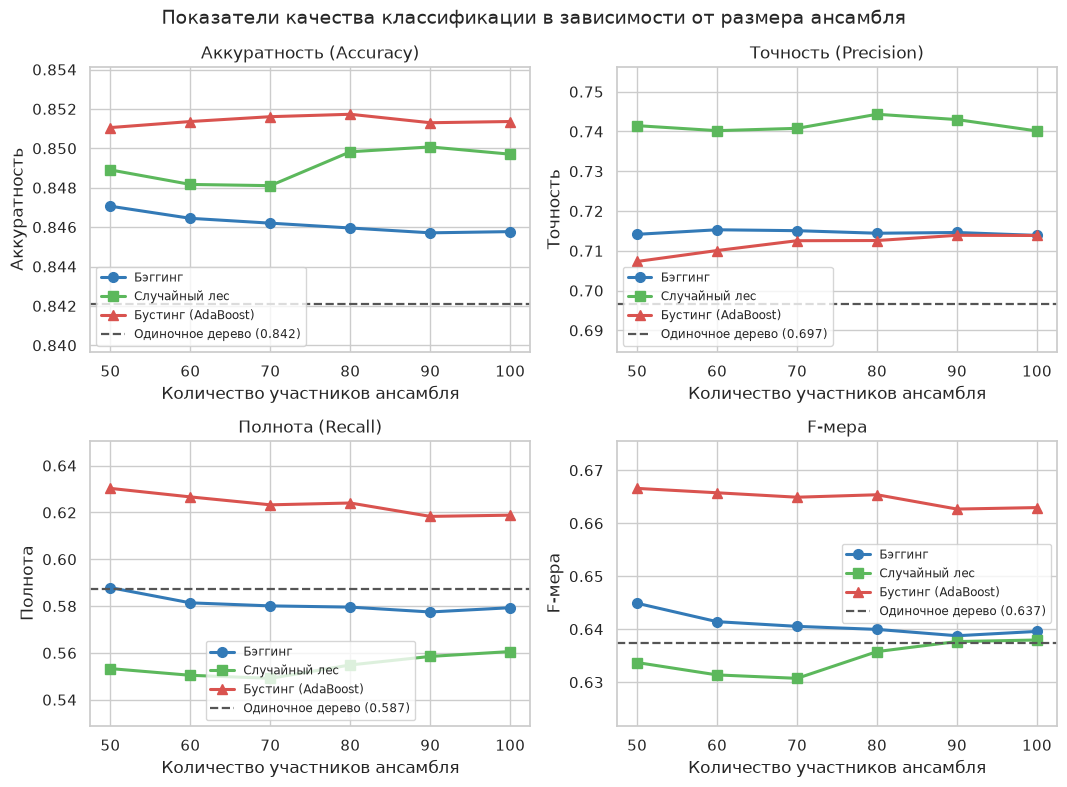

In [8]:
METRICS = [("accuracy", "Аккуратность (Accuracy)"), ("precision", "Точность (Precision)"),
           ("recall", "Полнота (Recall)"), ("f1", "F-мера")]
MARKERS = {"bagging": "o", "random_forest": "s", "boosting": "^"}
COLORS = {"bagging": "#337ab7", "random_forest": "#5cb85c", "boosting": "#d9534f"}

fig, axes = plt.subplots(2, 2, figsize=(10.8, 8))
for ax, (metric, label) in zip(axes.ravel(), METRICS):
    for technique in TECHNIQUES:
        sub = df_exp[df_exp["technique"] == technique]
        ax.plot(sub["n_estimators"], sub[metric], marker=MARKERS[technique], markersize=7,
                linewidth=2.2, color=COLORS[technique], label=TECHNIQUE_LABEL[technique])
    ax.axhline(baseline[metric], color="#555", linestyle="--", linewidth=1.6,
               label=f"Одиночное дерево ({baseline[metric]:.3f})")
    ax.set_title(label, fontsize=12.5)
    ax.set_xlabel("Количество участников ансамбля")
    ax.set_ylabel(label.split(" (")[0])
    ax.set_xticks(SIZES)
    ax.margins(y=0.25)
    ax.legend(fontsize=8.5)

fig.suptitle("Показатели качества классификации в зависимости от размера ансамбля",
             fontsize=13.5)
fig.tight_layout()
plt.show()

### Рисунок 2. Сходимость ансамбля: от 1 до 100 участников

Диаграмма из п. 3 задания охватывает диапазон 50–100 участников, где кривые уже плоские.
Чтобы было видно, где именно ансамбль набирает качество, тот же набор деревьев снят и на
меньших размерах — от одного участника.

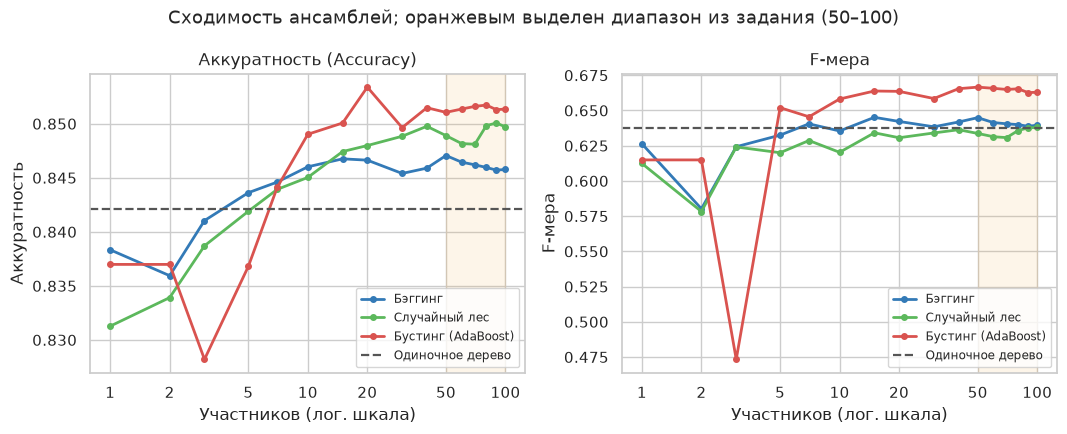

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.4))
for ax, (metric, label) in zip(axes, [METRICS[0], METRICS[3]]):
    for technique in TECHNIQUES:
        sub = df_all[df_all["technique"] == technique]
        ax.plot(sub["n_estimators"], sub[metric], marker="o", markersize=4,
                linewidth=2, color=COLORS[technique], label=TECHNIQUE_LABEL[technique])
    ax.axhline(baseline[metric], color="#555", linestyle="--", linewidth=1.6,
               label="Одиночное дерево")
    ax.axvspan(50, 100, color="#f0ad4e", alpha=0.12)
    ax.set_xscale("log")
    ax.set_xticks([1, 2, 5, 10, 20, 50, 100])
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.set_title(label, fontsize=12.5)
    ax.set_xlabel("Участников (лог. шкала)")
    ax.set_ylabel(label.split(" (")[0])
    ax.legend(fontsize=8.5, loc="lower right")

fig.suptitle("Сходимость ансамблей; оранжевым выделен диапазон из задания (50–100)",
             fontsize=13)
fig.tight_layout()
plt.show()

### Рисунок 3. Сравнение техник при 100 участниках с одиночным деревом

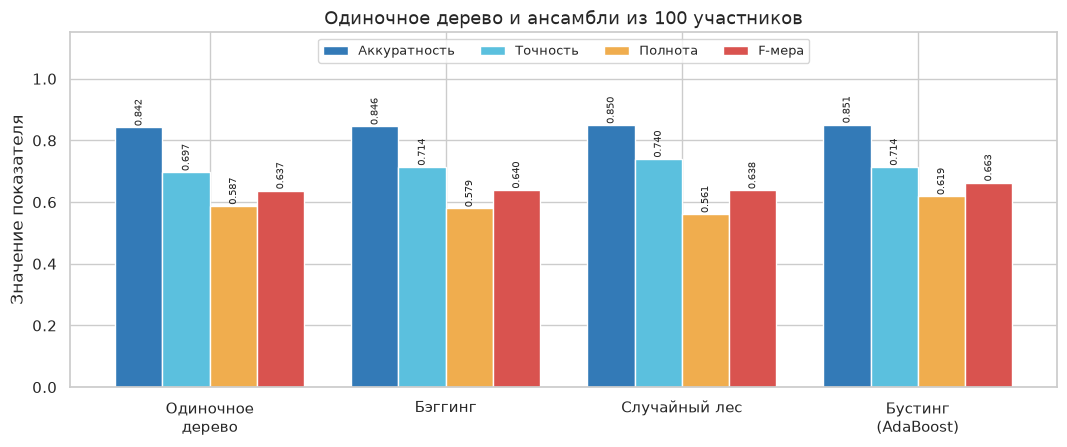

In [10]:
best = df_exp[df_exp["n_estimators"] == 100]
labels = ["Одиночное\nдерево"] + [TECHNIQUE_LABEL[t].replace(" (", "\n(") for t in TECHNIQUES]
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(10.8, 4.6))
bar_colors = ["#337ab7", "#5bc0de", "#f0ad4e", "#d9534f"]
for i, ((metric, label), color) in enumerate(zip(METRICS, bar_colors)):
    values = [baseline[metric]] + [best[best["technique"] == t][metric].iloc[0]
                                   for t in TECHNIQUES]
    bars = ax.bar(x + (i - 1.5) * 0.2, values, 0.2, label=label.split(" (")[0], color=color)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.012,
                f"{bar.get_height():.3f}", ha="center", fontsize=7.5, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Значение показателя")
ax.set_ylim(0, 1.15)
ax.legend(fontsize=9, ncol=4, loc="upper center")
ax.set_title("Одиночное дерево и ансамбли из 100 участников", fontsize=13)
fig.tight_layout()
plt.show()

## 7. Выводы

**Все три ансамбля точнее одиночного дерева, но выигрыш скромный.** Одиночное дерево даёт
аккуратность 0.8421, бэггинг — около 0.846, случайный лес — около 0.849, бустинг — 0.851.
То есть ансамбль из ста деревьев покупает примерно **0.4–0.9 процентного пункта**
аккуратности ценой стократного роста вычислений. Это нормальная для данного набора картина:
предел точности задаёт не неустойчивость дерева, а принципиальная неразделимость классов по
имеющимся 13 признакам — заметная часть респондентов с одинаковыми анкетными данными имеет
разный доход, и никакой ансамбль этого не исправит.

**Бустинг заметно выигрывает у остальных техник.** Его F-мера 0.663–0.667 против 0.639–0.645
у бэггинга, 0.631–0.638 у случайного леса и 0.637 у одиночного дерева — это **плюс 2.5–2.9
пункта** к одиночному дереву, тогда как бэггинг даёт меньше пункта, а случайный лес по
F-мере вообще не превосходит одиночное дерево. Причина в том, с чем борется каждая техника.
Бэггинг и лес усредняют независимые деревья и снижают **разброс**; но наше дерево глубины 6
с ограничением `min_samples = 100` и так неглубокое и переобучено слабо — гасить почти
нечего. Бустинг же целенаправленно снижает **смещение**: каждое следующее дерево обучается
на записях, где ошиблись предыдущие, то есть ансамбль последовательно добирает те
закономерности, которые одно дерево выразить не способно.

**Случайный лес показывает самый интересный перекос.** Его точность (precision) — самая
высокая среди всех, 0.740–0.744 против 0.697 у одиночного дерева, но полнота падает с 0.587
до 0.550–0.561, и в сумме F-мера оказывается даже чуть ниже, чем у одиночного дерева.
Объяснение — в сочетании простого большинства голосов с дисбалансом классов. Класс `>50K`
составляет 24 % выборки, поэтому у большинства деревьев в спорных листьях побеждает метка
`<=50K`. Чтобы ансамбль ответил `>50K`, так должна проголосовать больше половины деревьев —
условие заметно более строгое, чем у одиночного дерева. В итоге лес отвечает `>50K` реже, но
точнее. Если задача требует не пропускать высокодоходных респондентов, порог голосования
нужно сдвигать (отвечать `>50K`, например, уже при 35 % голосов).

**В диапазоне 50–100 участников показатели практически не меняются.** Размах всех кривых на
Рисунке 1 — в пределах 0.2–0.6 процентного пункта, причём направление непостоянно: у
бэггинга лучший результат на 50 участниках, у случайного леса — на 90, у бустинга — на 80.
Эти колебания лежат внутри погрешности оценки на тестовой выборке из 16 281 записи
(около ±0.6 п. п.), то есть **содержательной зависимости в этом диапазоне нет**.

Рисунок 2 объясняет, почему: ансамбль набирает почти всё своё качество на первых **10–20
участниках**, а дальше кривая выходит на плато. F-мера бустинга равна 0.658 уже при десяти
участниках и 0.663 при ста; у бэггинга — 0.636 при десяти и 0.640 при ста. Голосование
стабилизируется, как только участников хватает для устойчивого большинства, и дальнейшее
добавление деревьев меняет исход лишь в единичных спорных случаях.

**На самых малых размерах видны две аномалии**, и обе объяснимы. При двух участниках F-мера
проседает у всех трёх техник (бэггинг 0.626 → 0.580, случайный лес 0.612 → 0.578): чтобы
ансамбль из двух деревьев ответил `>50K`, так должны проголосовать **оба**, поскольку при
равенстве голосов побеждает класс большинства, — условие вдвое строже, и полнота падает.
У бустинга на трёх участниках F-мера обваливается до 0.473: в первых раундах AdaBoost веса
$\alpha_m$ ещё крупные и один неудачный участник способен перевесить остальных. К пятому —
десятому участнику обе аномалии исчезают.

**Практический вывод:** увеличивать ансамбль сверх 20–30 участников на этом наборе
бессмысленно — время обучения растёт линейно (165 с на 100 деревьев бэггинга, 91 с на
бустинг, 74 с на случайный лес), а качество нет. Если же выбирать технику, то на этих данных
выигрывает бустинг: он даёт и лучшую аккуратность, и лучшую F-меру, и обучается вдвое
быстрее бэггинга за счёт неглубоких деревьев.